<a href="https://colab.research.google.com/github/Eikthyrnir/uam-cv-sim-to-real-interpretability/blob/main/DIMO_detection_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wizja komputerowa, dane syntetyczne i testowanie architektur

**Projekty dla studentów V roku / ostatniego semestru. Realizacja w parach dwuosobowych.**

# **Zasady ogólne**

**Każdy projekt jest realizowany przez dokładnie dwie osoby.** Temat ma prowadzić do kompletnego, mierzalnego eksperymentu z użyciem modeli wizyjnych: klasyfikacji, detekcji, segmentacji, pseudoetykietowania, samonadzorowanego uczenia reprezentacji albo analizy luki domenowej. Projekty mogą mocniej akcentować generowanie danych syntetycznych albo testowanie architektur, ale każdy projekt musi kończyć się wynikami ilościowymi i jakościowymi.

· Każda para musi udostępnić publiczne lub dostępne dla prowadzącego repozytorium GitHub z kodem, konfiguracjami, instrukcją uruchomienia, skryptami przygotowania danych i wynikami eksperymentów.

· Każda para musi przygotować dokument wynikowy, najlepiej w formacie PDF lub Google Docs, opisujący cel, dane, metody, architektury, eksperymenty, wyniki, wizualizacje, błędy i ograniczenia.

· Link do repozytorium oraz link do dokumentu wynikowego muszą zostać wpisane do arkusza Google Sheets: [arkusz projektów](https://docs.google.com/spreadsheets/d/1HeEo42lNxoAGrou7ehcJk4KBIXR4Gv7RgMd3FmzLE0I/edit?usp=sharing).

· W arkuszu powinny znaleźć się co najmniej: numer projektu, imiona i nazwiska studentów, link do repozytorium, link do raportu, link do danych/artefaktów/modeli, krótki opis finalnego wariantu eksperymentu oraz status projektu.

· Zbiory danych wskazane poniżej są publicznie dostępne lub powszechnie używane w badaniach. Przed użyciem należy sprawdzić i respektować licencję konkretnego zbioru, obrazu i adnotacji; nie wszystkie zbiory są stricte CC0/public domain.

# **Minimalny zakres wyników**

· Dla lżejszych projektów klasyfikacyjnych lub segmentacyjnych oczekiwane jest około 15-30 sensownych konfiguracji lub wariantów eksperymentalnych.

· Dla cięższych projektów detekcyjnych oczekiwane jest około 8-15 konfiguracji, ale z pełniejszą analizą kosztu obliczeniowego, błędów i transferu domenowego.

· Każdy projekt musi zawierać punkt odniesienia, warianty porównawcze, tabele metryk, wykresy, wizualizacje wyników, przykłady błędów oraz interpretowalność: Grad-CAM, mapy uwagi, aktywacje, filtry lub osadzenia.

· Raport powinien mieć strukturę krótkiego artykułu: wstęp i pytanie badawcze, przegląd literatury, opis danych, metoda, protokół eksperymentów, wyniki, analiza jakościowa, ograniczenia, wnioski i instrukcja reprodukcji.


## **7\. Co sieci naprawdę uczą się z danych syntetycznych? Aktywacje, filtry i skróty decyzyjne**

**Kierunek:** interpretowalność / testowanie architektur

**Zadanie wizyjne:** klasyfikacja lub detekcja

**Publicznie dostępne zbiory danych:** COCO, Open Images, własny zbiór Blender, RarePlanes

**Pytanie badawcze:** Czy model trenowany na syntetykach uczy się obiektu, czy raczej artefaktów renderingu, tła, tekstur i innych skrótów decyzyjnych?

**Opis projektu:** To projekt diagnostyczny. Para trenuje ten sam model na różnych reżimach danych: tylko dane rzeczywiste, tylko dane syntetyczne, słaba randomizacja syntetyczna, silna randomizacja syntetyczna i mieszanka danych. Następnie analizuje aktywacje warstw, mapy uwagi, Grad-CAM oraz przypadki błędów. Celem jest wykrycie, kiedy syntetyki tworzą bias tła, bias tekstury lub bias kształtu.

**Modele i metody do przetestowania:**

· ResNet/ConvNeXt dla klasyfikacji

· YOLOv10 lub Faster R-CNN dla detekcji

· ViT/DINOv2 dla analizy uwagi

**Wymagane eksperymenty:**

· porównanie 4-5 reżimów danych

· analiza wrażliwości na zasłanianie fragmentów obrazu: usuwanie tła, tekstury, części obiektu

· UMAP/t-SNE osadzeń cech dla danych rzeczywistych i syntetycznych

· analiza 50 poprawnych i 50 błędnych predykcji

**Wymagane wyniki i analiza:**

· dokładność lub mAP

· co najmniej 50 wizualizacji Grad-CAM / mapy uwagi

· mapy filtrów lub aktywacji wybranych warstw

· ranking najczęstszych skrótów decyzyjnych

· sekcja w raporcie: kiedy syntetyki pomagają, a kiedy szkodzą

**Linki:** [pytorch-grad-cam](https://github.com/jacobgil/pytorch-grad-cam); [DINOv2](https://github.com/facebookresearch/dinov2); [COCO](https://cocodataset.org/); [Open Images](https://storage.googleapis.com/openimages/web/index.html); [RarePlanes](https://www.iqt.org/library/the-rareplanes-dataset); [ConvNeXt V2](https://github.com/facebookresearch/ConvNeXt-V2)


In [1]:
# Set seed for reproducibility
import torch

RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)

In [2]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

## Step 1: Mount Google Drive
To avoid downloading massive files every time your session disconnects, we can save the dataset to Google Drive (if you have enough space). Otherwise, you can use the local `/content/` storage, but remember it will be cleared after the session ends.

In [3]:
from google.colab import drive
import os

# Mount Google Drive (Optional but recommended if you have space)
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
PROJECT_DIR = '/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO'

os.makedirs(PROJECT_DIR, exist_ok=True)

models_dir = os.path.join(PROJECT_DIR, 'models')
os.makedirs(models_dir, exist_ok=True)

## Step 2: Download the Dataset

### Download from Tim's Google Drive (much faster)

In [5]:
!mkdir /content/DIMO_archives

In [6]:
# !gdown --id 1py7xaJpql7a6SrS9N5JF0xANLpbYZ4yM -O /content/DIMO_archives/dimo.tar

In [7]:
# !gdown --id 1TyINalV-nfdbbalOzcebp4tH9_K-ibI5 -O /content/DIMO_archives/real_d415.tar

In [8]:
# !gdown 1xCHhENLfAZDgOErz4TWL-FhMBnJ8uhVO -O /content/DIMO_archives/dimo_small.tar

In [9]:
# alternative
# !cp /content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/dimo_small.tar /content/DIMO_archives/dimo_small.tar

In [10]:
!gdown 1UZghk46xe_9E0ylHc5ONcBYWHsX3Qs6U -O /content/DIMO_archives/DIMO_experiment_subsets.tar

Downloading...
From (original): https://drive.google.com/uc?id=1UZghk46xe_9E0ylHc5ONcBYWHsX3Qs6U
From (redirected): https://drive.google.com/uc?id=1UZghk46xe_9E0ylHc5ONcBYWHsX3Qs6U&confirm=t&uuid=0b6f27d9-af75-43d8-ad6a-6bbd859d0c48
To: /content/DIMO_archives/DIMO_experiment_subsets.tar
100% 5.25G/5.25G [01:28<00:00, 59.0MB/s]


## Upzip

### 10k Subset of dimo-small

In [11]:
!mkdir -p /content/dimo_small
!tar -xf /content/DIMO_archives/DIMO_experiment_subsets.tar -C /content/dimo_small --strip-components=1

dimo_ds_path = '/content/dimo_small'

## Install libs


In [12]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 119.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=90d7f739db85f700d604419b38665c3b814e4a07abdfdfe3d17543c42644bfd1
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [13]:
# We will use trimesh to easily load the 3D .ply models
!pip install trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 41.7 MB/s eta 0:00:00


In [14]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 62.3 MB/s eta 0:00:00


In [15]:
!pip install effdet timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 10.2 MB/s eta 0:00:00


## Utility functions

In [16]:
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import to_pil_image

def filter_predictions(output, score_threshold=0.5):
    "Funkcja filtrowania predykcji"
    boxes = output["boxes"].detach().cpu()
    labels = output["labels"].detach().cpu()
    scores = output["scores"].detach().cpu()

    keep = scores >= score_threshold

    return {
        "boxes": boxes[keep],
        "labels": labels[keep],
        "scores": scores[keep],
    }

def draw_target(image_tensor, true_target):
    if len(true_target["boxes"]) == 0:
        return image_tensor

    # Convert labels tensor to a list of strings for drawing
    label_texts = [str(label) for label in true_target["labels"].tolist()]

    drawn = draw_bounding_boxes(
        image_tensor,
        boxes=true_target["boxes"],
        labels=label_texts,
        colors="lime",
        width=2,
        font_size=18
    )

    return drawn

def draw_predictions(image_tensor, prediction):
    if len(prediction["boxes"]) == 0:
        return image_tensor

    label_texts = [
        f"Obj {label}: {score:.2f}"
        for label, score in zip(prediction["labels"].tolist(), prediction["scores"].tolist())
    ]

    drawn = draw_bounding_boxes(
        image_tensor,
        boxes=prediction["boxes"],
        labels=label_texts,
        colors="red",
        width=2,
        font_size=18
    )

    return drawn

In [17]:
import numpy as np
import trimesh
import os
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

# Cache for 3D models to speed up projection across multiple images
models_dir = Path(dimo_ds_path) / "models"
models_cache = {}

def get_model_vertices(obj_id):
    if obj_id not in models_cache:
        model_path = os.path.join(models_dir, f"obj_{int(obj_id):06d}.ply")
        mesh = trimesh.load(model_path)
        models_cache[obj_id] = mesh.vertices
    return models_cache[obj_id]

In [18]:
from torch.utils.tensorboard import SummaryWriter
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import os
import time

def train_one_epoch(model, optimizer, data_loader, device, epoch, num_epochs):
    model.train()
    epoch_train_loss = 0

    for images, targets in tqdm(data_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_train_loss += losses.item()

    return epoch_train_loss / len(data_loader)

def evaluate(model, data_loader, device, desc_prefix="Val"):
    # 1. Get validation loss (torchvision models must be in .train() mode to return losses)
    model.train()
    epoch_loss = 0
    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc=f"{desc_prefix} Loss", leave=False):
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            epoch_loss += losses.item()
    avg_loss = epoch_loss / max(1, len(data_loader))

    # 2. Get mAP (torchvision models must be in .eval() mode to return predictions)
    model.eval()
    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)
    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc=f"{desc_prefix} mAP", leave=False):
            images = list(img.to(device) for img in images)
            outputs = model(images)

            preds = []
            for output in outputs:
                preds.append({
                    'boxes': output['boxes'].cpu(),
                    'scores': output['scores'].cpu(),
                    'labels': output['labels'].cpu()
                })

            targs = []
            for target in targets:
                targs.append({
                    'boxes': target['boxes'].cpu(),
                    'labels': target['labels'].cpu()
                })

            metric.update(preds, targs)

    mAP_results = metric.compute()
    return avg_loss, mAP_results

def run_experiment(model, optimizer, lr_scheduler, train_loader, val_loader, test_loader, run_name, num_epochs=5):
    run_dir = os.path.join(PROJECT_DIR, 'runs', run_name)
    writer_train = SummaryWriter(log_dir=os.path.join(run_dir, 'train'))
    writer_val = SummaryWriter(log_dir=os.path.join(run_dir, 'val'))
    writer_main = SummaryWriter(log_dir=run_dir) # Main writer for HParams

    print(f"\n========== Starting Experiment: {run_name} ==========")
    for epoch in range(num_epochs):
        start_time = time.time()

        # Train
        train_loss = train_one_epoch(model, optimizer, train_loader, device, epoch, num_epochs)
        lr_scheduler.step()

        # Validate
        val_loss, val_map_res = evaluate(model, val_loader, device, desc_prefix=f"Epoch {epoch+1}/{num_epochs} [Val]")

        # Log metrics
        writer_train.add_scalar('Loss/Epoch', train_loss, epoch)
        writer_val.add_scalar('Loss/Epoch', val_loss, epoch)
        writer_val.add_scalar('mAP_50_95/Epoch', val_map_res['map'].item(), epoch)
        writer_val.add_scalar('mAP_50/Epoch', val_map_res['map_50'].item(), epoch)

        print(f"Epoch [{epoch+1}/{num_epochs}] | Time: {time.time() - start_time:.1f}s | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val mAP: {val_map_res['map'].item():.4f}")

    # Test on independent Test set
    print("\n--- Running Independent Test Set Evaluation ---")
    test_loss, test_map_res = evaluate(model, test_loader, device, desc_prefix="[Test]")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test mAP (IoU=0.50:0.95): {test_map_res['map'].item():.4f}")
    print(f"Test mAP@0.50:            {test_map_res['map_50'].item():.4f}")

    # Log final results to the HPARAMS tab in TensorBoard
    hparams = {'dataset_regime': run_name, 'epochs': num_epochs}
    metrics = {
        'hparam/test_loss': test_loss,
        'hparam/test_mAP': test_map_res['map'].item(),
        'hparam/test_mAP_50': test_map_res['map_50'].item()
    }
    writer_main.add_hparams(hparams, metrics)

    writer_train.close()
    writer_val.close()
    writer_main.close()

    return test_map_res

In [86]:
def train_hf_transformer_epoch(model, optimizer, data_loader, device, epoch, num_epochs):
    model.train()
    epoch_train_loss = 0

    for batch in tqdm(data_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False):
        pixel_values = batch["pixel_values"].to(device)
        kwargs = {"pixel_values": pixel_values}
        if "pixel_mask" in batch:
            kwargs["pixel_mask"] = batch["pixel_mask"].to(device)

        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]
        kwargs["labels"] = labels

        outputs = model(**kwargs)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        # Clip grad norm to avoid exploding gradients in transformers
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
        optimizer.step()

        epoch_train_loss += loss.item()

    return epoch_train_loss / len(data_loader)

def evaluate_hf_transformer(model, processor, data_loader, device, desc_prefix="Val"):
    model.eval()
    epoch_loss = 0
    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)

    with torch.no_grad():
        for batch in tqdm(data_loader, desc=f"{desc_prefix}", leave=False):
            pixel_values = batch["pixel_values"].to(device)
            kwargs = {"pixel_values": pixel_values}
            if "pixel_mask" in batch:
                kwargs["pixel_mask"] = batch["pixel_mask"].to(device)

            labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]
            kwargs["labels"] = labels

            outputs = model(**kwargs)
            epoch_loss += outputs.loss.item()

            # For Post-processing: we need the target sizes (H, W)
            target_sizes = torch.tensor([p.shape[1:] for p in pixel_values]).to(device)

            # Model outputs relative coordinates, processor converts them to absolute image coordinates
            results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.0)

            preds = []
            for res in results:
                preds.append({
                    'boxes': res['boxes'].cpu(),
                    'scores': res['scores'].cpu(),
                    'labels': res['labels'].cpu()
                })

            targs = []
            for t, size in zip(labels, target_sizes):
                h, w = size
                # HF Ground Truths are normalized [center_x, center_y, width, height]
                # We need to un-normalize and convert to [xmin, ymin, xmax, ymax] for torchmetrics
                boxes = t['boxes']
                unnorm_boxes = boxes * torch.tensor([w, h, w, h], dtype=torch.float32).to(device)
                cx, cy, bw, bh = unnorm_boxes.unbind(-1)
                xmin = cx - 0.5 * bw
                ymin = cy - 0.5 * bh
                xmax = cx + 0.5 * bw
                ymax = cy + 0.5 * bh
                abs_boxes = torch.stack([xmin, ymin, xmax, ymax], dim=-1)

                # Handle key differences in label naming (class_labels vs labels depending on processor)
                cls_key = 'class_labels' if 'class_labels' in t else 'labels'
                targs.append({
                    'boxes': abs_boxes.cpu(),
                    'labels': t[cls_key].cpu()
                })

            metric.update(preds, targs)

    mAP_results = metric.compute()
    avg_loss = epoch_loss / max(1, len(data_loader))
    return avg_loss, mAP_results

def run_hf_transformer_experiment(model, processor, optimizer, train_loader, val_loader, test_loader, run_name, num_epochs=5, lr_scheduler=None):
    run_dir = os.path.join(PROJECT_DIR, 'runs', run_name)
    writer_train = SummaryWriter(log_dir=os.path.join(run_dir, 'train'))
    writer_val = SummaryWriter(log_dir=os.path.join(run_dir, 'val'))
    writer_main = SummaryWriter(log_dir=run_dir)

    print(f"\n========== Starting HF Transformer Experiment: {run_name} ==========")
    for epoch in range(num_epochs):
        start_time = time.time()

        # Train
        train_loss = train_hf_transformer_epoch(model, optimizer, train_loader, device, epoch, num_epochs)

        if lr_scheduler is not None:
            lr_scheduler.step()

        # Validate
        val_loss, val_map_res = evaluate_hf_transformer(model, processor, val_loader, device, desc_prefix=f"Epoch {epoch+1}/{num_epochs} [Val]")

        # Log metrics
        writer_train.add_scalar('Loss/Epoch', train_loss, epoch)
        writer_val.add_scalar('Loss/Epoch', val_loss, epoch)
        writer_val.add_scalar('mAP_50_95/Epoch', val_map_res['map'].item(), epoch)
        writer_val.add_scalar('mAP_50/Epoch', val_map_res['map_50'].item(), epoch)

        print(f"Epoch [{epoch+1}/{num_epochs}] | Time: {time.time() - start_time:.1f}s | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val mAP: {val_map_res['map'].item():.4f}")

    # Test on independent Test set
    if test_loader is not None:
        print("\n--- Running Independent Test Set Evaluation ---")
        test_loss, test_map_res = evaluate_hf_transformer(model, processor, test_loader, device, desc_prefix="[Test]")
        print(f"Test Loss: {test_loss:.4f}")
        print(f"Test mAP (IoU=0.50:0.95): {test_map_res['map'].item():.4f}")
        print(f"Test mAP@0.50:            {test_map_res['map_50'].item():.4f}")

        hparams = {'dataset_regime': run_name, 'epochs': num_epochs}
        metrics = {
            'hparam/test_loss': test_loss,
            'hparam/test_mAP': test_map_res['map'].item(),
            'hparam/test_mAP_50': test_map_res['map_50'].item()
        }
        writer_main.add_hparams(hparams, metrics)

    writer_train.close()
    writer_val.close()
    writer_main.close()

    return test_map_res if test_loader else val_map_res


## Load Dataset using Official DIMO Loader
Instead of parsing JSONs manually, use the provided `dimo_loader.py` to structure the dataset.

In [19]:
!git clone https://github.com/pderoovere/dimo.git /content/dimo_repo

Cloning into '/content/dimo_repo'...
remote: Enumerating objects: 221, done.
remote: Counting objects: 100% (221/221), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 221 (delta 88), reused 185 (delta 61), pack-reused 0 (from 0)
Receiving objects: 100% (221/221), 6.44 MiB | 26.39 MiB/s, done.
Resolving deltas: 100% (88/88), done.


In [20]:
import sys
import os
# Ensure the current directory is in the path to import dimo_loader
if '/content' not in sys.path:
    sys.path.append('/content')

from dimo_repo.scripts.dimo_loader import DimoLoader
from pathlib import Path

In [21]:
# Set path to the extracted dimo dataset folder
dimo_ds_path = Path('/content/dimo_small')

In [22]:
dimo_loader = DimoLoader()

dimo_ds = dimo_loader.load(
    dimo_ds_path,
    cameras=[
        "real_d415",
        "real_jaigo",
        "real_l515",
      # exclude real_mvbluefox since this folder contains gray folder for gray images instead of rgb.
      # DimoLoader can't handle this and it's also easier to only train on rgb images
      #  "real_mvbluefox",
        "sim_jaigo"
    ])

Loading real_d415
Loading real_jaigo
Loading real_l515
Loading sim_jaigo


## Dataset insights

In [23]:
import pandas as pd

# Prepare a list to hold all the flattened records
records = []

# Iterate through the top-level keys (cameras and 'models')
for cam_name, scenes in dimo_ds.items():
    if cam_name == 'models':
        continue # Skip the 3D models metadata for the main dataframe

    for scene_list_idx, scene in enumerate(scenes):

        scene_id = scene['id']
        for image_list_idx, img in enumerate(scene['images']):
            img_id = img['id']
            img_path = str(img['path'])
            num_objects = len(img['objects'])

            if not os.path.exists(img['path']):
                continue

            image_data = {
                    'camera': cam_name,
                    'scene_id': scene_id,
                    'scene_list_idx': scene_list_idx,
                    'image_id': img_id,
                    'image_list_idx': image_list_idx,
                    'image_path': img_path,
                    'total_objects_in_image': num_objects
                }
            # Use .get() to safely handle cases where scene_info might be missing
            image_data.update(img.get('scene_info', {}))

            # --------- We probably don't need row per obj, row per img is enough --------
            # for obj in img['objects']:
            #     # Crucial: make a copy so we don't overwrite previous objects from the same image
            #     obj_record = image_data.copy()
            #     obj_record['object_id'] = obj['id']

            #     records.append(obj_record)

            records.append(image_data)

# Create the DataFrame
df_dimo = pd.DataFrame(records)

In [24]:
import pandas as pd

# Group by the specified columns and count occurrences
# dropna=False ensures we don't drop rows where fields like 'exposure' are NaN (e.g., real images)
grouped_counts = df_dimo.groupby(
    ['light', 'exposure', 'environment_rotation', 'carrier'],
    dropna=False
).size().reset_index(name='count')

# Sort by count descending to see the most common configurations
grouped_counts = grouped_counts.sort_values(by='count', ascending=False)

print(f"Total images: {len(df_dimo)}")
print(f"Total unique combinations: {len(grouped_counts)}")
display(grouped_counts.head(20))

Total images: 39618
Total unique combinations: 13454


,light,exposure,environment_rotation,carrier,count
7257,lightRoomImage_hdr,11.000000,0.000000,2,2926
7255,lightRoomImage_hdr,11.000000,0.000000,0,1935
4703,darkRoomImage_hdr,7.000000,180.000000,1,1916
4702,darkRoomImage_hdr,7.000000,180.000000,0,1850
7256,lightRoomImage_hdr,11.000000,0.000000,1,1835
0,0,NaN,NaN,0,1696
1,0,NaN,NaN,1,1690
5,1,NaN,NaN,2,1672
4,1,NaN,NaN,1,1655
2,0,NaN,NaN,2,1650


In [25]:
df_dimo.groupby(
    ['light'],
    dropna=False
).size().reset_index(name='count').sort_values(by='count', ascending=False)

,light,count
20,lightRoomImage_hdr,6696
13,darkRoomImage_hdr,5671
0,0,5036
1,1,4964
14,empty_warehouse_01_4k,598
12,colorful_studio_4k,584
35,vintage_measuring_lab_4k,580
6,artist_workshop_4k,574
7,auto_service_4k,567
9,blinds_4k,566


In [26]:
df_dimo.groupby(
    ['camera', 'total_objects_in_image'],
    dropna=False
).size().reset_index(name='count').sort_values(by='total_objects_in_image', ascending=True)

,camera,total_objects_in_image,count
0,real_d415,1,395
6,real_jaigo,1,394
12,real_l515,1,401
18,sim_jaigo,1,3705
13,real_l515,4,11
1,real_d415,4,17
19,sim_jaigo,4,78
7,real_jaigo,4,15
14,real_l515,5,2481
20,sim_jaigo,5,22495


In [27]:
df_dimo

,camera,scene_id,scene_list_idx,image_id,image_list_idx,image_path,total_objects_in_image,light,carrier,parts,viewpoint,exposure,environment_rotation
0,real_d415,000000,0,1,0,/content/dimo_small/real_d415/000000/rgb/00000...,1,0,0,1,0,NaN,NaN
1,real_d415,000000,0,4,3,/content/dimo_small/real_d415/000000/rgb/00000...,1,0,0,1,3,NaN,NaN
2,real_d415,000000,0,5,4,/content/dimo_small/real_d415/000000/rgb/00000...,1,0,0,1,4,NaN,NaN
3,real_d415,000000,0,6,5,/content/dimo_small/real_d415/000000/rgb/00000...,1,0,0,1,5,NaN,NaN
4,real_d415,000000,0,7,6,/content/dimo_small/real_d415/000000/rgb/00000...,1,0,0,1,6,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39613,sim_jaigo,000599_62,20830,4,4,/content/dimo_small/sim_jaigo/000599_62/rgb/00...,6,indoor_pool_4k,1,0,4,10.195874,144.510513
39614,sim_jaigo,000599_67,20831,3,3,/content/dimo_small/sim_jaigo/000599_67/rgb/00...,6,mutianyu_4k,1,0,3,13.378714,105.781166
39615,sim_jaigo,000599_67,20831,8,8,/content/dimo_small/sim_jaigo/000599_67/rgb/00...,6,mutianyu_4k,1,0,8,13.378714,105.781166
39616,sim_jaigo,000599_68,20832,9,9,/content/dimo_small/sim_jaigo/000599_68/rgb/00...,6,old_apartments_walkway_4k,1,0,9,10.583752,197.749359


## Split dataset into subsets

> Para trenuje ten sam model na różnych reżimach danych: tylko dane rzeczywiste, tylko dane syntetyczne, słaba randomizacja syntetyczna, silna randomizacja syntetyczna i mieszanka danych



In [28]:
import pandas as pd

# 1. Tylko dane rzeczywiste (Only real data)
df_real_only = df_dimo[df_dimo['camera'].str.startswith('real')].copy()

# 2. Tylko dane syntetyczne (All synthetic data)
df_sim_all = df_dimo[df_dimo['camera'] == 'sim_jaigo'].copy()

# Helper to identify 'Real-world lighting' in simulation
real_world_lights = ['lightRoomImage_hdr', 'darkRoomImage_hdr']

# 3. Słaba randomizacja syntetyczna (Weak randomization)
# We'll use simulation data with real-world lighting environments (allowing default rotations)
df_sim_weak_dr = df_sim_all[
    df_sim_all['light'].isin(real_world_lights)
].copy()

# 4. Silna randomizacja syntetyczna (Strong randomization)
# Simulation data with random HDRI lighting and random rotations
df_sim_strong_dr = df_sim_all[
    ~df_sim_all['light'].isin(real_world_lights)
].copy()

print("--- Dataset Splits for the Project ---")
print(f"1. Tylko dane rzeczywiste:       {len(df_real_only)} observations")
print(f"2. Tylko dane syntetyczne (all): {len(df_sim_all)} observations")
print(f"3. Słaba randomizacja:           {len(df_sim_weak_dr)} observations")
print(f"4. Silna randomizacja:           {len(df_sim_strong_dr)} observations")
print(f"5. Mieszanka danych (Real+Strong): would be calculated later to ensure 50/50 real/sim data split")


--- Dataset Splits for the Project ---
1. Tylko dane rzeczywiste:       10000 observations
2. Tylko dane syntetyczne (all): 29618 observations
3. Słaba randomizacja:           12367 observations
4. Silna randomizacja:           17251 observations
5. Mieszanka danych (Real+Strong): would be calculated later to ensure 50/50 real/sim data split


In [29]:
import os
import shutil
from sklearn.model_selection import train_test_split
from tqdm import tqdm

N_IMAGES_TO_KEEP = 1_000

regimes = {
    'real_only': df_real_only.sample(n=N_IMAGES_TO_KEEP, random_state=RANDOM_SEED),
    'sim_all': df_sim_all.sample(n=N_IMAGES_TO_KEEP, random_state=RANDOM_SEED),
    'sim_weak_dr': df_sim_weak_dr.sample(n=N_IMAGES_TO_KEEP, random_state=RANDOM_SEED),
    'sim_strong_dr': df_sim_strong_dr.sample(n=N_IMAGES_TO_KEEP, random_state=RANDOM_SEED),
}

regimes['mixed'] = pd.concat([
                        df_real_only.sample(n=int(N_IMAGES_TO_KEEP / 2), random_state=RANDOM_SEED),
                        df_sim_all.sample(n=int(N_IMAGES_TO_KEEP / 2), random_state=RANDOM_SEED),
                    ], ignore_index=True).sample(frac=1, random_state=RANDOM_SEED)

In [30]:
# Define a separate test set from real data (to be used consistently across all experiments)
N_TEST_IMAGES = 100

# Ensure no overlap with the existing 'real_only' regime used for train/val
used_real_indices = regimes['real_only'].index
df_real_remaining = df_real_only.drop(used_real_indices)

# Sample for the test set
df_real_test = df_real_remaining.sample(n=N_TEST_IMAGES, random_state=RANDOM_SEED)

## Create PyTorch Dataset

Implement a PyTorch Dataset class to load a subset of the DIMO data, returning images, labels and bounding boxes

In [31]:
import torch
import os
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

class DimoDetectionDataset(Dataset):
    def __init__(self, native_dimo_ds, image_set):
        self.samples = []
        self.target_size = (224, 224)
        # For torchvision detectors, we usually just convert to tensor (values 0-1)
        # Normalization is often handled inside the model (e.g., Faster R-CNN)
        self.transform = transforms.Compose([
            transforms.Resize(self.target_size),
            transforms.ToTensor(),
        ])

        # Iterate over the dataframe rows
        for idx, row in image_set.iterrows():
            cam = row['camera']
            # Use the new explicit list indices to fetch directly
            scene_idx = int(row['scene_list_idx'])
            img_idx = int(row['image_list_idx'])

            # Direct list indexing! Extremely fast O(1) lookup.
            try:
                img_data = native_dimo_ds[cam][scene_idx]['images'][img_idx]
            except (KeyError, IndexError):
                continue

            img_path = img_data['path']

            # Skip if the file is missing from the disk
            if not os.path.exists(img_path):
                continue

            K = np.array(img_data['camera']['K']).reshape(3, 3)

            bboxes = []
            labels = []

            for obj in img_data['objects']:
                if 'model_2cam' in obj:
                    obj_id = obj['id']
                    pose = np.array(obj['model_2cam'])
                    R = pose[:3, :3]
                    t = pose[:3, 3].reshape(3, 1)

                    # Project 3D to 2D to get the bounding box
                    vertices = get_model_vertices(obj_id)
                    pts_cam = (R @ vertices.T) + t
                    pts_2d = K @ pts_cam

                    u = pts_2d[0, :] / pts_2d[2, :]
                    v = pts_2d[1, :] / pts_2d[2, :]

                    xmin, xmax = np.min(u), np.max(u)
                    ymin, ymax = np.min(v), np.max(v)

                    # Add box and label (assume all objects are class 1 for now, 0 is background)
                    bboxes.append([xmin, ymin, xmax, ymax])
                    labels.append(obj_id)

            if bboxes:
                self.samples.append({
                    'img_path': img_path,
                    'bboxes': torch.tensor(bboxes, dtype=torch.float32),
                    'labels': torch.tensor(labels, dtype=torch.int64)
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(sample['img_path']).convert('RGB')
        orig_w, orig_h = img.size

        # Resize bounding boxes
        target_w, target_h = self.target_size
        scale_x = target_w / orig_w
        scale_y = target_h / orig_h

        boxes = sample['bboxes'].clone()
        boxes[:, 0] *= scale_x # xmin
        boxes[:, 2] *= scale_x # xmax
        boxes[:, 1] *= scale_y # ymin
        boxes[:, 3] *= scale_y # ymax

        # Transform image
        img_tensor = self.transform(img)

        target = {}
        target['boxes'] = boxes
        target['labels'] = sample['labels']

        return img_tensor, target


def collate_fn(batch):
    # Faster R-CNN expects a tuple of (images, targets) rather than stacked tensors
    # because the number of bounding boxes varies per image.
    return tuple(zip(*batch))

## Object Detection: Model & DataLoader
Faster R-CNN requires a custom `collate_fn` because each image can have a variable number of bounding boxes. We will use a pre-trained ResNet-50 FPN backbone and modify the box predictor head for our 2 classes (Background + Object).

In [32]:
import torch.optim as optim
import time
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import random_split, DataLoader

In [33]:
BATCH_SIZE = 32

In [34]:
# Create the PyTorch Dataset and DataLoader
test_dataset = DimoDetectionDataset(dimo_ds, df_real_test)
test_loader_det = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

In [35]:
detection_train_dataset = DimoDetectionDataset(dimo_ds, regimes['real_only'])

train_size = int(0.8 * len(detection_train_dataset))
val_size = len(detection_train_dataset) - train_size

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(detection_train_dataset, [train_size, val_size], generator=generator)

# Redefine train_loader_det and create val_loader_det using the collate_fn from previous cell
train_loader_det = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, collate_fn=collate_fn)
val_loader_det = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)
print(f"Created Train/Val split: {len(train_dataset)} train, {len(val_dataset)} val samples.")

Created Train/Val split: 800 train, 200 val samples.


In [36]:
# 7 classes: background (0) and objects (1 - 6)
NUM_CLASSES = 7

In [37]:
def get_fasterrcnn_resnet50_fpn_model(num_classes):
    # Load a pre-trained Faster R-CNN model
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # Replace the pre-trained head with a new one for our number of classes
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


detection_model = get_fasterrcnn_resnet50_fpn_model(NUM_CLASSES).to(device)

# Optimizer and Learning Rate Scheduler
params = [p for p in detection_model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=1e-2, momentum=0.9, weight_decay=0.0005)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 247MB/s]


In [38]:
## Alternative 1: Faster R-CNN with MobileNetV3 Backbone
# Instead of ResNet50, use lightweight `mobilenet_v3_large_fpn`.

import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_mobilenet_detection_model(num_classes):
    # Load a pre-trained Faster R-CNN model with a MobileNetV3 backbone
    model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(weights="DEFAULT")

    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # Replace the pre-trained head with a new one for our number of classes
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

# 7 classes: background (0) and objects (1 - 6)
mobilenet_model = get_mobilenet_detection_model(num_classes=NUM_CLASSES).to(device)

# Optimizer and Learning Rate Scheduler
params = [p for p in mobilenet_model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=1e-2, momentum=0.9, weight_decay=0.0005)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


100%|██████████| 74.2M/74.2M [00:00<00:00, 244MB/s]


In [39]:
## CURRENTLY NOT USED
## Alternative 2: EfficientDet (via effdet)
# EfficientDet is a highly scalable single-stage detector.
# We will use the `effdet` library which integrates smoothly with standard PyTorch.

from effdet import get_efficientdet_config, EfficientDet, DetBenchTrain
from effdet.efficientdet import HeadNet

# 1. Load config for a lightweight EfficientDet (D0)
config = get_efficientdet_config('tf_efficientdet_d0')

# For effdet, we specify the number of foreground classes (6 in our case)
config.num_classes = 6
config.image_size = (224, 224) # Match our dataloader size

# 2. Create the model structure
effdet_model = EfficientDet(config, pretrained_backbone=True)

# 3. Modify the classification head for our specific number of classes
effdet_model.class_net = HeadNet(config, num_outputs=config.num_classes)

# 4. Wrap it in DetBenchTrain.
# This built-in wrapper automatically computes loss when in .train() mode,
# very similar to how torchvision's Faster R-CNN behaves!
effdet_train_model = DetBenchTrain(effdet_model, config).to(device)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

## Transformer-based Detection: DETR
Let's use Hugging Face's `transformers` library to fine-tune a DETR model. DETR uses a ResNet backbone to extract features and a Transformer encoder-decoder architecture to predict bounding boxes directly.

In [40]:
!pip install -q transformers

In [41]:
from transformers import DetrImageProcessor, DetrForObjectDetection
import torch
import numpy as np
from PIL import Image


processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")

class DETRDataset(DimoDetectionDataset): # Inheriting from our original dataset!
    def __init__(self, native_dimo_ds, image_set, processor):
        # Call the parent init to handle all the 3D-to-2D bounding box projections
        super().__init__(native_dimo_ds, image_set)
        self.processor = processor

    def __getitem__(self, idx):
        sample = self.samples[idx]
        image = Image.open(sample['img_path']).convert("RGB")

        annotations = {'image_id': idx, 'annotations': []}

        # Parent class stores bboxes as a tensor: [xmin, ymin, xmax, ymax]
        for box, label in zip(sample['bboxes'], sample['labels']):
            xmin, ymin, xmax, ymax = box.tolist()
            annotations['annotations'].append({
                'bbox': [xmin, ymin, xmax - xmin, ymax - ymin],
                'category_id': label.item(),
                'area': (xmax - xmin) * (ymax - ymin),
                'iscrowd': 0
            })

        encoding = self.processor(images=image, annotations=annotations, return_tensors="pt")
        pixel_values = encoding["pixel_values"].squeeze() # remove batch dim
        target = encoding["labels"][0]
        return pixel_values, target

def detr_collate_fn(batch):
    pixel_values = [item[0] for item in batch]
    encoding = processor.pad(pixel_values, return_tensors="pt")
    labels = [item[1] for item in batch]
    return {'pixel_values': encoding['pixel_values'], 'pixel_mask': encoding['pixel_mask'], 'labels': labels}


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

In [59]:
# Initialize DETR Datasets and DataLoaders
detr_train_dataset = DETRDataset(dimo_ds, regimes['real_only'], processor)
detr_test_dataset = DETRDataset(dimo_ds, df_real_test, processor)

# Split train dataset
train_size_detr = int(0.8 * len(detr_train_dataset))
val_size_detr = len(detr_train_dataset) - train_size_detr
detr_train_ds, detr_val_ds = torch.utils.data.random_split(detr_train_dataset, [train_size_detr, val_size_detr], generator=torch.Generator().manual_seed(RANDOM_SEED))

detr_train_loader = DataLoader(detr_train_ds, batch_size=8, shuffle=True, collate_fn=detr_collate_fn, num_workers=2)
detr_val_loader = DataLoader(detr_val_ds, batch_size=8, shuffle=False, collate_fn=detr_collate_fn, num_workers=2)
detr_test_loader = DataLoader(detr_test_dataset, batch_size=8, shuffle=False, collate_fn=detr_collate_fn, num_workers=2)


In [64]:
# Load DETR model with correct number of labels
id2label = {i: f"obj{i}" for i in range(1, NUM_CLASSES)}
id2label[0] = "background"
label2id = {v: k for k, v in id2label.items()}

model_detr = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50",
    revision="no_timm", # Avoid timm warnings
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
).to(device)

optimizer_detr = torch.optim.AdamW(model_detr.parameters(), lr=1e-4, weight_decay=1e-4)


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                            | Status   |                                                                                      
-------------------------------+----------+--------------------------------------------------------------------------------------
class_labels_classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([92, 256]) vs model:torch.Size([8, 256])
class_labels_classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([92]) vs model:torch.Size([8])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [65]:
num_epochs_detr = 5

detr_results = run_hf_transformer_experiment(
    model=model_detr,
    processor=processor,
    optimizer=optimizer_detr,
    train_loader=detr_train_loader,
    val_loader=detr_val_loader,
    test_loader=detr_test_loader,
    run_name='detr_resnet50_dimo_real_only',
    num_epochs=num_epochs_detr
)


========== Starting HF Transformer Experiment: detr_resnet50_dimo_real_only ==========


Epoch 1/5 [Train]:   2%|▏         | 2/100 [00:03<02:26,  1.49s/it]Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 116, in auto_conversion
    raise e
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 95, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 76, in get_conversion_pr_reference
    raise OSError(
OSError: Could not create safetensors conversion PR. The repo does not a

Epoch [1/5] | Time: 129.9s | Train Loss: 3.0930 | Val Loss: 2.9603 | Val mAP: 0.0013


Epoch [2/5] | Time: 130.8s | Train Loss: 2.8876 | Val Loss: 2.7929 | Val mAP: 0.0043


Epoch [3/5] | Time: 129.6s | Train Loss: 2.7431 | Val Loss: 2.6992 | Val mAP: 0.0044


Epoch [4/5] | Time: 129.8s | Train Loss: 2.5833 | Val Loss: 2.6021 | Val mAP: 0.0073


Epoch [5/5] | Time: 130.0s | Train Loss: 2.5814 | Val Loss: 2.5218 | Val mAP: 0.0084

--- Running Independent Test Set Evaluation ---


Test Loss: 2.5426
Test mAP (IoU=0.50:0.95): 0.0095
Test mAP@0.50:            0.0389


### Visualizing DETR Cross-Attention Maps
DETR's transformer decoder attends to specific parts of the image feature map when predicting each bounding box. By extracting these cross-attention weights, we can visually inspect exactly where the model is looking for each object.

Visualizing DETR Attentions:


/usr/local/lib/python3.12/dist-packages/torchvision/utils.py:375: UserWarning: Argument 'font_size' will be ignored since 'font' is not set.
  warnings.warn("Argument 'font_size' will be ignored since 'font' is not set.")


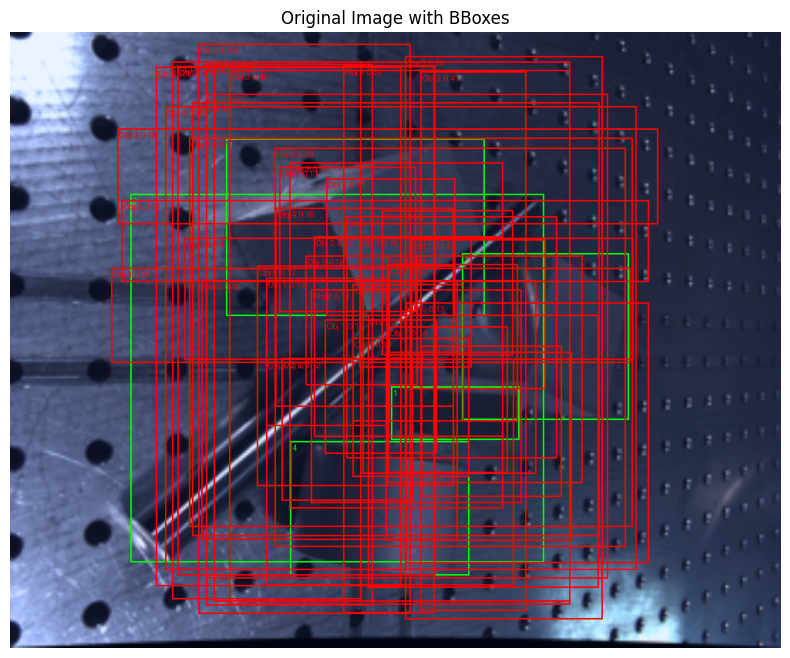

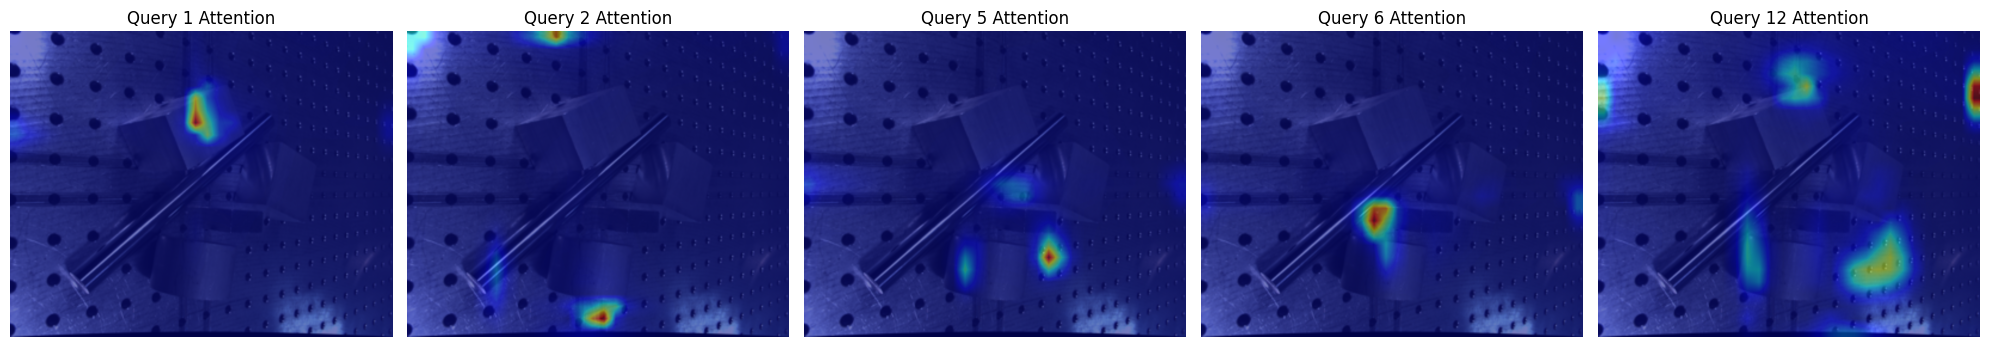

In [105]:
# --- Visualize DETR ---
# Using the generic visualization function defined in the YOLOS section
print("Visualizing DETR Attentions:")
visualize_transformer_attentions(
    model=model_detr,
    processor=processor,  # DETR processor is stored in the `processor` variable
    dataset=detr_val_ds,
    sample_idx=0,
    device=device,
    model_type='detr',
    conf_threshold=0.1
)


In [75]:
detr_save_path = os.path.join(models_dir, 'detr_resnet50_dimo_real_only_epoch_5_checkpoint.pth')
detr_checkpoint = {
    'epoch': num_epochs_detr,
    'model_state_dict': model_detr.state_dict(),
    'optimizer_state_dict': optimizer_detr.state_dict()
}
torch.save(detr_checkpoint, detr_save_path)

## Training Loop
In PyTorch, Faster R-CNN automatically computes the classification and bounding box regression losses when in `.train()` mode.

In [ ]:
model = mobilenet_model
# Run the real_only experiment
num_epochs = 5
test_metrics = run_experiment(
    model=model,
    optimizer=optimizer,
    lr_scheduler=lr_scheduler,
    train_loader=train_loader_det,
    val_loader=val_loader_det,
    test_loader=test_loader_det,
    # run_name='fasterrcnn_resnet50_fpn_real_only',
    run_name='fasterrcnn_mobilenet_v3_large_fpn_real_only',
    num_epochs=num_epochs
)

In [ ]:
models_dir = os.path.join(PROJECT_DIR, 'models')
!mkdir -p "{models_dir}"
# model_save_path = os.path.join(models_dir, 'fasterrcnn_resnet50_fpn_real_only_multiclass_epoch_5_checkpoint.pth')
model_save_path = os.path.join(models_dir, 'fasterrcnn_mobilenet_v3_large_fpn_dimo_real_only_multiclass_epoch_5_checkpoint.pth')

checkpoint = {
    'epoch': num_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'lr_scheduler_state_dict': lr_scheduler.state_dict()
}

torch.save(checkpoint, model_save_path)

In [ ]:
%load_ext tensorboard

In [ ]:
%tensorboard --logdir {os.path.join(PROJECT_DIR, 'runs')}

## Evaluation & Visualization
Let's put the model in `.eval()` mode and visualize the predicted bounding boxes compared to the ground truth.

In [ ]:
model.eval()

num_vis = 4
fig, axes = plt.subplots(1, num_vis, figsize=(20, 5))

with torch.no_grad():
    for i in range(num_vis):
        img_t, target = test_dataset[i]

        # Forward pass (expects a list of tensors)
        prediction = model([img_t.to(device)])[0]

        img_display = draw_target(img_t, target)
        prediction = filter_predictions(prediction)
        img_display = draw_predictions(img_display, prediction)

        ax = axes[i]
        ax.imshow(to_pil_image(img_display))
        ax.set_title(f"Sample {i+1}")
        ax.axis('off')

plt.suptitle("Faster R-CNN: Ground Truth (Lime) vs Prediction (Red)", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Initialize the mAP metric
metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)

model.eval()
with torch.no_grad():
    for images, targets in tqdm(test_loader_det, desc="Calculating mAP"):
        images = list(img.to(device) for img in images)

        # Get model predictions
        outputs = model(images)

        # Format predictions for torchmetrics
        preds = []
        for output in outputs:
            preds.append({
                'boxes': output['boxes'].cpu(),
                'scores': output['scores'].cpu(),
                'labels': output['labels'].cpu()
            })

        # Format targets for torchmetrics
        targs = []
        for target in targets:
            targs.append({
                'boxes': target['boxes'].cpu(),
                'labels': target['labels'].cpu()
            })

        # Update metric state
        metric.update(preds, targs)

# Compute final mAP metrics
print("Computing final mAP (this might take a few seconds)...")
result = metric.compute()

print("\n--- Faster R-CNN Validation Metrics ---")
print(f"mAP (IoU=0.50:0.95): {result['map'].item():.4f}")
print(f"mAP@0.50:            {result['map_50'].item():.4f}")
print(f"mAP@0.75:            {result['map_75'].item():.4f}")

# If you want to see per-class mAP:
if 'map_per_class' in result:
    print("\nPer-class mAP (IoU=0.50:0.95):")
    for class_idx, class_map in zip(result['classes'].tolist(), result['map_per_class'].tolist()):
        print(f"  Class {class_idx}: {class_map:.4f}")


In [ ]:
target_layers = {
    'get_mobilenet_detection_model': lambda model: [list(model.backbone.body.children())[-1]],
    'get_detection_model': lambda model: [model.backbone.body.layer4]
}

In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pytorch_grad_cam import EigenCAM, GradCAMPlusPlus, HiResCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Wrapper to make Faster R-CNN compatible with pytorch_grad_cam
class DetModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        outputs = self.model(x)
        # For gradient-based CAMs (GradCAM++, HiResCAM), we need a differentiable output.
        # Summing all box confidence scores forces gradients to highlight all detected objects!
        if len(outputs[0]['scores']) > 0:
            return outputs[0]['scores'].sum().view(1, 1)
        return torch.zeros((x.size(0), 1), device=x.device, requires_grad=True)

wrapped_model = DetModelWrapper(model)
wrapped_model.eval()

# Safely get the last layer of the MobileNetV3 backbone
target_layers = target_layers['get_mobilenet_detection_model'](model)

img_t, target = detection_train_dataset[0]
input_tensor = img_t.unsqueeze(0).to(device)

# Prepare image for visualization
rgb_img = img_t.numpy().transpose(1, 2, 0)
rgb_img = np.clip(rgb_img, 0, 1)

# Dictionary of CAM methods to run
cam_algorithms = {
    "EigenCAM": EigenCAM,
    "GradCAM++": GradCAMPlusPlus,
    "HiResCAM": HiResCAM
}

cam_images = {}

for name, CamClass in cam_algorithms.items():
    with CamClass(model=wrapped_model, target_layers=target_layers) as cam:
        # targets=None automatically uses our sum of scores output
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)
        grayscale_cam = grayscale_cam[0]
        cam_images[name] = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# Plotting
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# 1. Original Image
axes[0].imshow(to_pil_image(draw_target(img_t, target)))
axes[0].set_title("Original Image with GT BBoxes")
axes[0].axis('off')

# 2-4. CAM Outputs
for idx, (name, img) in enumerate(cam_images.items()):
    axes[idx + 1].imshow(img)
    axes[idx + 1].set_title(f"{name} (MobileNetV3 Last Layer)")
    axes[idx + 1].axis('off')

plt.suptitle("Faster R-CNN: Multiple CAM Algorithms", fontsize=18)
plt.tight_layout()
plt.show()


## Train YOLOv10
YOLO models require the dataset to be organized in folders with `.txt` label files. Let's install the library and convert our data.

In [ ]:
!pip install ultralytics

In [ ]:
import os
import shutil
import yaml
from tqdm import tqdm
from PIL import Image

yolo_dir = os.path.join(PROJECT_DIR, 'yolo_dataset')
os.makedirs(f'{yolo_dir}/images/train', exist_ok=True)
os.makedirs(f'{yolo_dir}/labels/train', exist_ok=True)
os.makedirs(f'{yolo_dir}/images/val', exist_ok=True)
os.makedirs(f'{yolo_dir}/labels/val', exist_ok=True)

def convert_to_yolo(dataset, split_name):
    for idx in tqdm(range(len(dataset)), desc=f"Converting {split_name}"):
        orig_idx = dataset.indices[idx]
        sample = dataset.dataset.samples[orig_idx]
        img_path = sample['img_path']

        # Copy image
        ext = os.path.splitext(img_path)[1]
        new_img_name = f"{split_name}_{idx}{ext}"
        shutil.copy(img_path, f'{yolo_dir}/images/{split_name}/{new_img_name}')

        # Get image dimensions for YOLO normalization
        with Image.open(img_path) as img:
            w, h = img.size

        boxes = sample['bboxes']
        labels = sample['labels']
        label_file = f'{yolo_dir}/labels/{split_name}/{split_name}_{idx}.txt'

        # Write bounding boxes in YOLO format: class x_center y_center width height
        with open(label_file, 'w') as f:
            for box, label in zip(boxes, labels):
                xmin, ymin, xmax, ymax = box.tolist()
                x_center = ((xmin + xmax) / 2) / w
                y_center = ((ymin + ymax) / 2) / h
                width = (xmax - xmin) / w
                height = (ymax - ymin) / h

                # Assuming our labels are 1-6, YOLO requires 0-indexed classes
                yolo_label = int(label) - 1
                f.write(f"{yolo_label} {x_center} {y_center} {width} {height}\n")

# Convert train and val datasets
convert_to_yolo(train_dataset, 'train')
convert_to_yolo(val_dataset, 'val')

# Create YAML config file
yaml_content = {
    'path': yolo_dir,
    'train': 'images/train',
    'val': 'images/val',
    'names': {0: 'obj1', 1: 'obj2', 2: 'obj3', 3: 'obj4', 4: 'obj5', 5: 'obj6'}
}
with open(f'{yolo_dir}/dataset.yaml', 'w') as f:
    yaml.dump(yaml_content, f)

print(f"\nYOLO dataset successfully created at {yolo_dir}")

Converting val: 100%|██████████| 200/200 [03:57<00:00,  1.19s/it]



YOLO dataset successfully created at /content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/yolo_dataset


In [ ]:
from ultralytics import YOLO

# Load the YOLOv10 Nano model
model_yolo = YOLO("yolov10n.pt")

# Train the model
results = model_yolo.train(
    data=os.path.join(PROJECT_DIR, 'yolo_dataset', 'dataset.yaml'),
    epochs=5,
    imgsz=224,
    batch=16,
    device=device,
    project=os.path.join(PROJECT_DIR, 'yolo_runs'),
    name='yolov10_dimo'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, ker

### YOLOv10 Attention Visualization (EigenCAM)
Gradient-based CAMs often struggle with YOLO architectures due to their complex non-differentiable detection heads. Instead, we compute **EigenCAM**, which uses Principal Component Analysis (PCA) directly on the CNN's deep activation maps to show where the network is "looking".

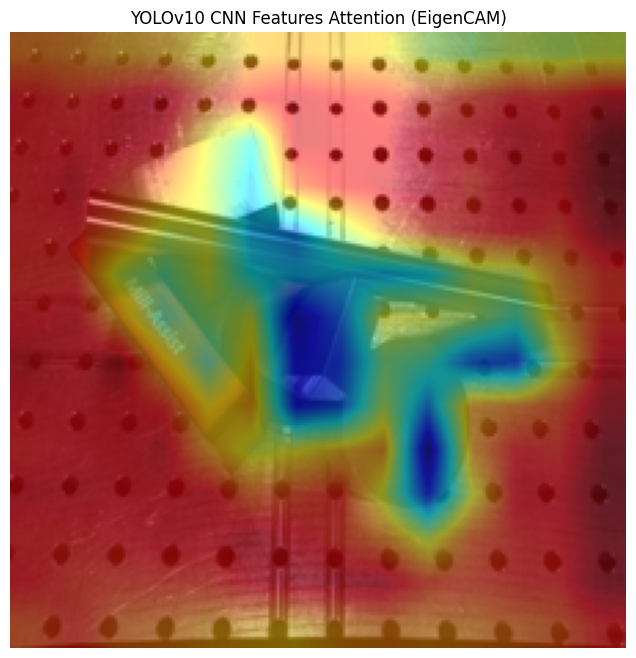

In [ ]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

# Hook mechanism to extract intermediate features from the model
class Hook:
    def __init__(self, module):
        self.features = None
        self.hook = module.register_forward_hook(self.hook_fn)
    def hook_fn(self, module, input, output):
        self.features = output
    def close(self):
        self.hook.remove()

# Prepare the exact same image used in Faster R-CNN visualization
img_path = detection_train_dataset.samples[0]['img_path']
img = Image.open(img_path).convert('RGB').resize((224, 224))
img_tensor = transforms.ToTensor()(img).unsqueeze(0).to(device)
rgb_img = np.array(img) / 255.0

# Access the inner PyTorch model and hook into a deep CNN layer (e.g., layer 15 in the neck)
pt_model = model_yolo.model.to(device)
target_layer = pt_model.model[17]
hook = Hook(target_layer)

# Run inference
with torch.no_grad():
    pt_model(img_tensor)

# Extract features (C, H, W)
features = hook.features[0].cpu().numpy()
hook.close()

# Compute the first Principal Component (PCA) of the feature map (EigenCAM)
C, H, W = features.shape
reshaped_features = features.reshape(C, -1).T
reshaped_features = reshaped_features - reshaped_features.mean(axis=0)

U, S, Vt = np.linalg.svd(reshaped_features, full_matrices=False)
pc1 = U[:, 0].reshape(H, W)

# Normalize and resize the CAM
pc1 = (pc1 - pc1.min()) / (pc1.max() - pc1.min() + 1e-5)
pc1_resized = cv2.resize(pc1, (224, 224))

# Overlay Heatmap on Image
heatmap = cv2.applyColorMap(np.uint8(255 * pc1_resized), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
cam_image = 0.5 * heatmap + 0.5 * rgb_img
cam_image = np.clip(cam_image, 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(cam_image)
plt.title("YOLOv10 CNN Features Attention (EigenCAM)")
plt.axis('off')
plt.show()

### Save YOLO dataset as archive

In [ ]:
import tarfile

yolo_archive_path = os.path.join(PROJECT_DIR, 'yolo_dataset.tar')

with tarfile.open(yolo_archive_path, "w") as tar:
    tar.add(yolo_dir, arcname=os.path.basename(yolo_dir))

print(f"YOLO dataset archived to: {yolo_archive_path}")

### Extract YOLO dataset from archive

In [ ]:
yolo_extract_dir = os.path.join(PROJECT_DIR, 'yolo_dataset_extracted')
!mkdir -p "{yolo_extract_dir}"
!tar -xf "{yolo_archive_path}" -C "{yolo_extract_dir}"
print(f"YOLO dataset extracted to: {yolo_extract_dir}")

## Pure Transformer Detection: YOLOS
Unlike DETR, which uses a ResNet (CNN) backbone to extract features before the transformer, **YOLOS** (You Only Look at One Sequence) uses a pure Vision Transformer (ViT). It splits the image into patches and processes them entirely using self-attention.

In [88]:
from transformers import YolosImageProcessor, YolosForObjectDetection
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
import torch

# 1. Load the pure-ViT YOLOS processor
yolos_processor = YolosImageProcessor.from_pretrained("hustvl/yolos-small")

# 2. Reuse our DETRDataset since YOLOS uses the exact same COCO-style target format!
yolos_train_dataset = DETRDataset(dimo_ds, regimes['real_only'], yolos_processor)

def yolos_collate_fn(batch):
    pixel_values = [item[0] for item in batch]

    # Images have variable sizes depending on aspect ratio, pad to max in batch
    max_h = max(p.shape[1] for p in pixel_values)
    max_w = max(p.shape[2] for p in pixel_values)

    padded_pixel_values = []
    for p in pixel_values:
        # pad format: (left, right, top, bottom)
        pad_w = max_w - p.shape[2]
        pad_h = max_h - p.shape[1]
        padded_pixel_values.append(torch.nn.functional.pad(p, (0, pad_w, 0, pad_h)))

    pixel_values = torch.stack(padded_pixel_values)
    labels = [item[1] for item in batch]
    return {'pixel_values': pixel_values, 'labels': labels}

yolos_train_loader = DataLoader(yolos_train_dataset, batch_size=8, shuffle=True, collate_fn=yolos_collate_fn, num_workers=2)

# 3. Load the YOLOS model (Swapping out the original classification head for our 7 classes)
model_yolos = YolosForObjectDetection.from_pretrained(
    "hustvl/yolos-small",
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
).to(device)

optimizer_yolos = torch.optim.AdamW(model_yolos.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_yolos = CosineAnnealingLR(optimizer_yolos, T_max=num_epochs_yolos, eta_min=1e-6)

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

YolosForObjectDetection LOAD REPORT from: hustvl/yolos-small
Key                                     | Status   |                                                                                      
----------------------------------------+----------+--------------------------------------------------------------------------------------
class_labels_classifier.layers.2.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([92]) vs model:torch.Size([8])          
class_labels_classifier.layers.2.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([92, 384]) vs model:torch.Size([8, 384])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [85]:
import torch
from torch.utils.data import DataLoader

# 1. Create a validation split for YOLOS so we can evaluate mAP during training
train_size_yolos = int(0.8 * len(yolos_train_dataset))
val_size_yolos = len(yolos_train_dataset) - train_size_yolos
yolos_train_ds, yolos_val_ds = torch.utils.data.random_split(
    yolos_train_dataset,
    [train_size_yolos, val_size_yolos],
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)

# Create a test dataset for YOLOS
yolos_test_dataset = DETRDataset(dimo_ds, df_real_test, yolos_processor)

# Override the train loader to use the split, and create the val and test loaders
yolos_train_loader = DataLoader(yolos_train_ds, batch_size=8, shuffle=True, collate_fn=yolos_collate_fn, num_workers=2)
yolos_val_loader = DataLoader(yolos_val_ds, batch_size=8, shuffle=False, collate_fn=yolos_collate_fn, num_workers=2)
yolos_test_loader = DataLoader(yolos_test_dataset, batch_size=8, shuffle=False, collate_fn=yolos_collate_fn, num_workers=2)

In [91]:
num_epochs_yolos = 10

yolos_results = run_hf_transformer_experiment(
    model=model_yolos,
    processor=yolos_processor,
    optimizer=optimizer_yolos,
    train_loader=yolos_train_loader,
    val_loader=yolos_val_loader,
    test_loader=yolos_test_loader,
    run_name='yolos_small_dimo_real_only',
    num_epochs=num_epochs_yolos,
    lr_scheduler=scheduler_yolos
)



========== Starting HF Transformer Experiment: yolos_small_dimo_real_only ==========


Epoch [1/10] | Time: 300.4s | Train Loss: 2.2026 | Val Loss: 1.8034 | Val mAP: 0.1284


Epoch [2/10] | Time: 298.9s | Train Loss: 1.6136 | Val Loss: 1.3981 | Val mAP: 0.2207


Epoch [3/10] | Time: 300.1s | Train Loss: 1.3895 | Val Loss: 1.2805 | Val mAP: 0.2804


Epoch [4/10] | Time: 299.7s | Train Loss: 1.2413 | Val Loss: 1.1079 | Val mAP: 0.3593


...

Epoch [7/10] | Time: 298.9s | Train Loss: 0.8945 | Val Loss: 0.8244 | Val mAP: 0.5258


Epoch [8/10] | Time: 299.6s | Train Loss: 0.7837 | Val Loss: 0.7580 | Val mAP: 0.5706


Epoch [9/10] | Time: 299.5s | Train Loss: 0.7183 | Val Loss: 0.6726 | Val mAP: 0.6170


Epoch [10/10] | Time: 299.9s | Train Loss: 0.6590 | Val Loss: 0.6429 | Val mAP: 0.6310

--- Running Independent Test Set Evaluation ---


Test Loss: 0.9335
Test mAP (IoU=0.50:0.95): 0.4977
Test mAP@0.50:            0.8037


### Save YOLOS Model

In [100]:
yolos_save_path = os.path.join(models_dir, 'yolos_small_dimo_real_only_epoch_5_checkpoint.pth')
yolos_checkpoint = {
    'epoch': num_epochs_yolos,
    'model_state_dict': model_yolos.state_dict(),
    'optimizer_state_dict': optimizer_yolos.state_dict(),
    'scheduler_state_dict': scheduler_yolos.state_dict()
}
torch.save(yolos_checkpoint, yolos_save_path)


### Load YOLOS Model from Checkpoint
To load the model, we instantiate the base model again and load the weights from our saved `model_state_dict`.

In [101]:
yolos_save_path = os.path.join(models_dir, 'yolos_small_dimo_real_only_epoch_5_checkpoint.pth')

# 1. Re-initialize the model architecture
loaded_model_yolos = YolosForObjectDetection.from_pretrained(
    "hustvl/yolos-small",
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
).to(device)

# 2. Re-initialize optimizer and scheduler with the new model's parameters
loaded_optimizer_yolos = torch.optim.AdamW(loaded_model_yolos.parameters(), lr=1e-4, weight_decay=1e-4)
loaded_scheduler_yolos = CosineAnnealingLR(loaded_optimizer_yolos, T_max=num_epochs_yolos, eta_min=1e-6)

# 3. Load the checkpoint states
checkpoint = torch.load(yolos_save_path, map_location=device)

loaded_model_yolos.load_state_dict(checkpoint['model_state_dict'])
loaded_optimizer_yolos.load_state_dict(checkpoint['optimizer_state_dict'])
loaded_scheduler_yolos.load_state_dict(checkpoint['scheduler_state_dict'])

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

YolosForObjectDetection LOAD REPORT from: hustvl/yolos-small
Key                                     | Status   |                                                                                      
----------------------------------------+----------+--------------------------------------------------------------------------------------
class_labels_classifier.layers.2.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([92]) vs model:torch.Size([8])          
class_labels_classifier.layers.2.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([92, 384]) vs model:torch.Size([8, 384])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


### Visualizing YOLOS Attention Maps
Unlike DETR, which has cross-attention between a CNN encoder and a transformer decoder, YOLOS is a pure Vision Transformer. It appends `[DET]` (detection) tokens to the sequence of image patches. To see where the model is looking for each object, we visualize the self-attention weights between these `[DET]` tokens and the original image patches in the final layer.

In [95]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
from torchvision.transforms.functional import to_pil_image

# --- Helper Functions ---
def get_ground_truth_dict(target, w, h):
    """Converts normalized YOLO ground truth boxes back to absolute pixel coordinates."""
    boxes = target['boxes']
    unnorm_boxes = boxes * torch.tensor([w, h, w, h], dtype=torch.float32)
    cx, cy, bw, bh = unnorm_boxes.unbind(-1)
    xmin = cx - 0.5 * bw
    ymin = cy - 0.5 * bh
    xmax = cx + 0.5 * bw
    ymax = cy + 0.5 * bh
    abs_boxes = torch.stack([xmin, ymin, xmax, ymax], dim=-1)

    cls_key = 'class_labels' if 'class_labels' in target else 'labels'
    return {
        "boxes": abs_boxes.cpu(),
        "labels": target[cls_key].cpu()
    }

def format_image_for_drawing(pixel_values):
    """Formats the raw tensor image for matplotlib and torchvision utilities."""
    img_plot = np.transpose(pixel_values.cpu().numpy()[0], (1, 2, 0))
    img_plot = (img_plot - img_plot.min()) / (img_plot.max() - img_plot.min())

    img_uint8 = (img_plot * 255).astype(np.uint8)
    img_tensor_uint8 = torch.from_numpy(img_uint8).permute(2, 0, 1)
    return img_plot, img_tensor_uint8

def plot_yolos_attentions(img_display, img_plot, attention_mean, queries_kept, num_queries, feature_map_h, feature_map_w, w, h):
    """Plots the original image along with the attention maps for the kept DET tokens."""
    num_boxes_to_show = min(len(queries_kept), 5)
    fig, axes = plt.subplots(1, num_boxes_to_show + 1, figsize=(16, 5))
    if num_boxes_to_show == 1:
        axes = [axes]

    axes[0].imshow(to_pil_image(img_display))
    axes[0].set_title("Original Image with BBoxes")
    axes[0].axis("off")

    for idx, query_idx in enumerate(queries_kept[:num_boxes_to_show]):
        # Row corresponding to the specific [DET] token's attention to all other tokens
        det_token_idx = -num_queries + query_idx.item()

        # Columns corresponding to the image patches
        patch_start_idx = 1
        patch_end_idx = 1 + feature_map_h * feature_map_w

        attn_map = attention_mean[det_token_idx, patch_start_idx:patch_end_idx].reshape(feature_map_h, feature_map_w).cpu().numpy()
        attn_map_resized = cv2.resize(attn_map, (w, h))

        ax = axes[idx + 1]
        ax.imshow(img_plot)
        ax.imshow(attn_map_resized, cmap='jet', alpha=0.5)
        ax.set_title(f"DET Token {query_idx.item()} Attention")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [103]:
import math

def visualize_transformer_attentions(model, processor, dataset, sample_idx, device, model_type='yolos', conf_threshold=0.5):
    """
    Universal function to visualize attention maps for Hugging Face transformer detectors (DETR and YOLOS).
    """
    model.eval()
    # Eager implementation often needed to correctly output attentions
    if hasattr(model.config, '_attn_implementation'):
        model.config._attn_implementation = "eager"

    pixel_values, target = dataset[sample_idx]
    pixel_values = pixel_values.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(pixel_values=pixel_values, output_attentions=True, return_dict=True)

    # Find predictions above our confidence threshold
    probas = outputs.logits.softmax(-1)[0, :, :-1]
    keep = probas.max(-1).values > conf_threshold
    queries_kept = keep.nonzero().squeeze(-1)

    if len(queries_kept) == 0:
        print(f"No objects detected with confidence > {conf_threshold} in this sample.")
        return

    # Setup image for drawing
    h, w = pixel_values.shape[-2:]
    img_plot, img_tensor_uint8 = format_image_for_drawing(pixel_values)

    # Post-process predictions to absolute coordinates
    target_sizes = torch.tensor([[h, w]]).to(device)
    results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=conf_threshold)[0]

    true_target_for_draw = get_ground_truth_dict(target, w, h)
    pred_for_draw = {
        "boxes": results["boxes"].cpu(),
        "labels": results["labels"].cpu(),
        "scores": results["scores"].cpu()
    }

    # Draw using our utility functions
    img_display = draw_target(img_tensor_uint8, true_target_for_draw)
    img_display = draw_predictions(img_display, pred_for_draw)

    num_boxes_to_show = min(len(queries_kept), 5)

    # 1. Plot the original image with bounding boxes separately (larger)
    plt.figure(figsize=(10, 8))
    plt.imshow(to_pil_image(img_display))
    plt.title("Original Image with BBoxes")
    plt.axis("off")
    plt.show()

    # 2. Plot the attention maps in a separate row
    fig, axes = plt.subplots(1, num_boxes_to_show, figsize=(4 * num_boxes_to_show, 4))
    if num_boxes_to_show == 1:
        axes = [axes]

    # --- Model-specific Attention Extraction ---
    if model_type == 'yolos':
        if outputs.attentions is None:
            print("Could not retrieve attention maps from the YOLOS outputs.")
            return
        attention_mean = outputs.attentions[-1].mean(dim=1)[0]
        patch_size = 16
        feature_map_h, feature_map_w = h // patch_size, w // patch_size
        num_queries = outputs.logits.shape[1]

        for idx, query_idx in enumerate(queries_kept[:num_boxes_to_show]):
            det_token_idx = -num_queries + query_idx.item()
            patch_start_idx = 1
            patch_end_idx = 1 + feature_map_h * feature_map_w

            attn_map = attention_mean[det_token_idx, patch_start_idx:patch_end_idx].reshape(feature_map_h, feature_map_w).cpu().numpy()
            attn_map_resized = cv2.resize(attn_map, (w, h))

            ax = axes[idx]
            ax.imshow(img_plot)
            ax.imshow(attn_map_resized, cmap='jet', alpha=0.5)
            ax.set_title(f"DET Token {query_idx.item()} Attention")
            ax.axis("off")

    elif model_type == 'detr':
        if outputs.cross_attentions is None:
            print("Could not retrieve cross-attention maps from the DETR outputs.")
            return
        attention_mean = outputs.cross_attentions[-1].mean(dim=1)[0]
        feature_map_h = math.ceil(h / 32)
        feature_map_w = math.ceil(w / 32)

        for idx, query_idx in enumerate(queries_kept[:num_boxes_to_show]):
            attn_map = attention_mean[query_idx.item()].reshape(feature_map_h, feature_map_w).cpu().numpy()
            attn_map_resized = cv2.resize(attn_map, (w, h))

            ax = axes[idx]
            ax.imshow(img_plot)
            ax.imshow(attn_map_resized, cmap='jet', alpha=0.5)
            ax.set_title(f"Query {query_idx.item()} Attention")
            ax.axis("off")

    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.12/dist-packages/torchvision/utils.py:375: UserWarning: Argument 'font_size' will be ignored since 'font' is not set.
  warnings.warn("Argument 'font_size' will be ignored since 'font' is not set.")


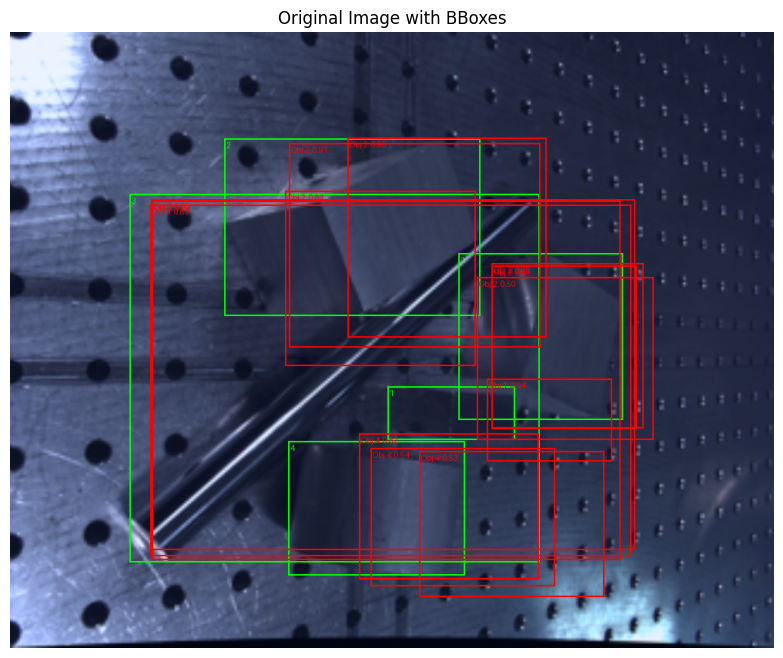

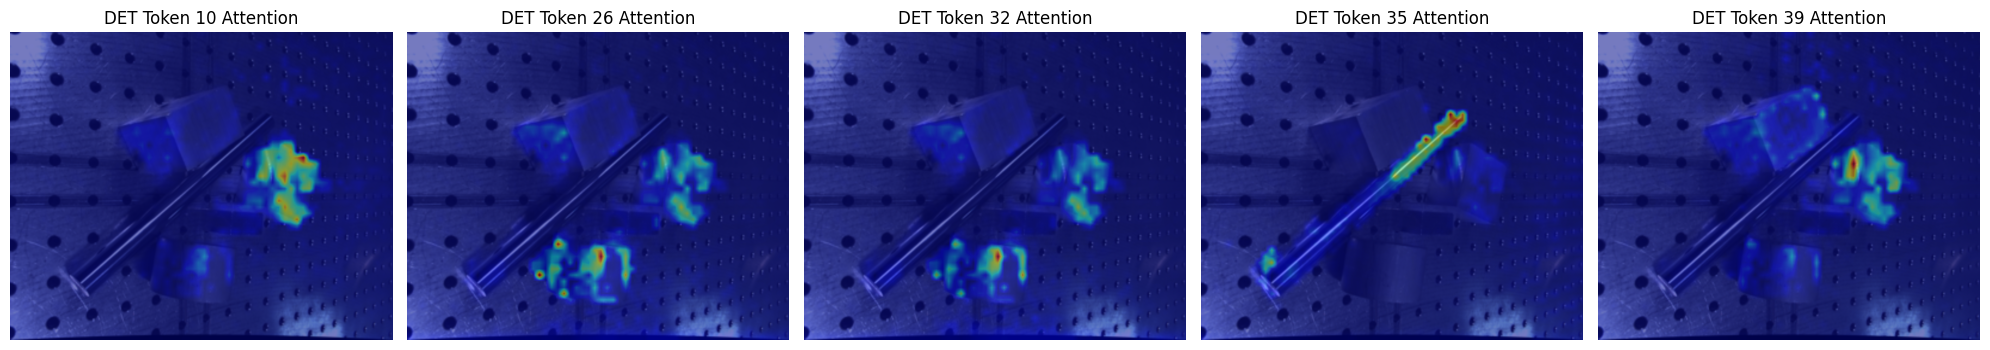

In [104]:
visualize_transformer_attentions(
    model=loaded_model_yolos,
    processor=yolos_processor,
    dataset=yolos_val_ds,
    sample_idx=0,
    device=device,
    model_type='yolos',
    conf_threshold=0.5
)